In [195]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)

print( 'All libraries imported successfully!')

All libraries imported successfully!


In [196]:

# Dataset Source: Store Sales - Kaggle

import pandas as pd
import numpy as np

np.random.seed(42)

# Load datasets
train = pd.read_csv("train.csv")
stores = pd.read_csv("stores.csv")
oil = pd.read_csv("oil.csv")

# Convert date columns
train['date'] = pd.to_datetime(train['date'])
oil['date'] = pd.to_datetime(oil['date'])

# Merge datasets
df = train.merge(stores, on='store_nbr', how='left')
df = df.merge(oil, on='date', how='left')

# Handle missing oil values
df['dcoilwtico'] = df['dcoilwtico'].fillna(method='ffill')

# Rename columns (clean style like reference)
df = pd.DataFrame({
    'Order Date': df['date'],
    'Store': df['store_nbr'],
    'Product': df['family'],
    'City': df['city'],
    'State': df['state'],
    'Sales': np.round(df['sales'], 2),
    'Promotion': df['onpromotion'],
    'Oil Price': np.round(df['dcoilwtico'], 2)
})

print(f' Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')

df.head()

 Dataset loaded: 3000888 rows × 8 columns


,Order Date,Store,Product,City,State,Sales,Promotion,Oil Price
0,2013-01-01,1,AUTOMOTIVE,Quito,Pichincha,0.0,0,NaN
1,2013-01-01,1,BABY CARE,Quito,Pichincha,0.0,0,NaN
2,2013-01-01,1,BEAUTY,Quito,Pichincha,0.0,0,NaN
3,2013-01-01,1,BEVERAGES,Quito,Pichincha,0.0,0,NaN
4,2013-01-01,1,BOOKS,Quito,Pichincha,0.0,0,NaN


In [197]:
print('=== Dataset Info ===')
df.info()
print('\n=== Statistical Summary ===')
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 8 columns):
 #   Column      Dtype         
---  ------      -----         
 0   Order Date  datetime64[ns]
 1   Store       int64         
 2   Product     object        
 3   City        object        
 4   State       object        
 5   Sales       float64       
 6   Promotion   int64         
 7   Oil Price   float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(3)
memory usage: 183.2+ MB

=== Statistical Summary ===


,Order Date,Store,Sales,Promotion,Oil Price
count,3000888,3.000888e+06,3.000888e+06,3.000888e+06,2.999106e+06
mean,2015-04-24 08:27:04.703088384,2.750000e+01,3.577757e+02,2.602770e+00,6.790992e+01
min,2013-01-01 00:00:00,1.000000e+00,0.000000e+00,0.000000e+00,2.619000e+01
25%,2014-02-26 18:00:00,1.400000e+01,0.000000e+00,0.000000e+00,4.637000e+01
50%,2015-04-24 12:00:00,2.750000e+01,1.100000e+01,0.000000e+00,5.341000e+01
75%,2016-06-19 06:00:00,4.100000e+01,1.958500e+02,0.000000e+00,9.572000e+01
max,2017-08-15 00:00:00,5.400000e+01,1.247170e+05,7.410000e+02,1.106200e+02
std,NaN,1.558579e+01,1.101998e+03,1.221888e+01,2.566939e+01


In [198]:
# Check missing values
print('=== Missing Values ===')
print(df.isnull().sum())
print(f'\nDate Range: {df["Order Date"].min()} → {df["Order Date"].max()}')

=== Missing Values ===
Order Date       0
Store            0
Product          0
City             0
State            0
Sales            0
Promotion        0
Oil Price     1782
dtype: int64

Date Range: 2013-01-01 00:00:00 → 2017-08-15 00:00:00


In [199]:
# Ensure datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Drop duplicates if any
before = len(df)
df.drop_duplicates(inplace=True)
print(f'Duplicates removed: {before - len(df)}')

# Handle missing values
df.dropna(subset=['Sales', 'Order Date'], inplace=True)

# Remove negative sales (data quality check)
df = df[df['Sales'] > 0]

print(f'Clean dataset: {df.shape[0]} rows')
     

Duplicates removed: 0
Clean dataset: 2061758 rows


In [200]:
# Feature Engineering

# Extract time-based features
df['Year']        = df['Order Date'].dt.year
df['Month']       = df['Order Date'].dt.month
df['Quarter']     = df['Order Date'].dt.quarter
df['Week']        = df['Order Date'].dt.isocalendar().week.astype(int)
df['DayOfWeek']   = df['Order Date'].dt.dayofweek
df['DayOfYear']   = df['Order Date'].dt.dayofyear

# Weekend & seasonal flags
df['IsWeekend']   = df['DayOfWeek'].isin([5, 6]).astype(int)
df['IsQ4']        = (df['Quarter'] == 4).astype(int)   # Holiday season


# Monthly aggregation (Time Series)

monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()

# Create proper date column
monthly_sales['Date'] = pd.to_datetime(
    monthly_sales[['Year', 'Month']].assign(Day=1)
)

# Sort chronologically
monthly_sales = monthly_sales.sort_values('Date').reset_index(drop=True)


# Lag Features (Past Sales)

monthly_sales['Sales_Lag1']  = monthly_sales['Sales'].shift(1)
monthly_sales['Sales_Lag3']  = monthly_sales['Sales'].shift(3)
monthly_sales['Sales_Lag12'] = monthly_sales['Sales'].shift(12)


# Rolling Statistics

monthly_sales['Rolling_Mean_3'] = monthly_sales['Sales'].rolling(3).mean()
monthly_sales['Rolling_Mean_6'] = monthly_sales['Sales'].rolling(6).mean()
monthly_sales['Rolling_Std_3']  = monthly_sales['Sales'].rolling(3).std()


# Month & Quarter Features

monthly_sales['Month_Num'] = monthly_sales['Month']
monthly_sales['Quarter']   = monthly_sales['Month'].apply(lambda m: (m-1)//3 + 1)
monthly_sales['IsQ4']      = (monthly_sales['Quarter'] == 4).astype(int)

# Remove NaN values created by lag/rolling
monthly_sales.dropna(inplace=True)

print('Feature engineering complete!')
monthly_sales.head(10)

Feature engineering complete!


,Year,Month,Sales,Date,Sales_Lag1,Sales_Lag3,Sales_Lag12,Rolling_Mean_3,Rolling_Mean_6,Rolling_Std_3,Month_Num,Quarter,IsQ4
12,2014,1,18911640.91,2014-01-01,15803116.79,11775619.98,10327624.65,1.569044e+07,1.372961e+07,3.278993e+06,1,1,0
13,2014,2,12038352.95,2014-02-01,18911640.91,12356559.43,9658959.51,1.558437e+07,1.377970e+07,3.441861e+06,2,1,0
14,2014,3,20365584.34,2014-03-01,12038352.95,15803116.79,11428496.85,1.710519e+07,1.520848e+07,4.447824e+06,3,1,0
15,2014,4,12861251.22,2014-04-01,20365584.34,18911640.91,10993464.61,1.508840e+07,1.538942e+07,4.588663e+06,4,2,0
16,2014,5,13379784.82,2014-05-01,12861251.22,12038352.95,11597704.35,1.553554e+07,1.555996e+07,4.190968e+06,5,2,0
17,2014,6,13319958.13,2014-06-01,13379784.82,20365584.34,11689344.71,1.318700e+07,1.514610e+07,2.836866e+05,6,2,0
18,2014,7,19421891.16,2014-07-01,13319958.13,12861251.22,11257400.65,1.537388e+07,1.523114e+07,3.505810e+06,7,3,0
19,2014,8,13885176.62,2014-08-01,19421891.16,13379784.82,11737788.92,1.554234e+07,1.553894e+07,3.371653e+06,8,3,0
20,2014,9,20022416.02,2014-09-01,13885176.62,13319958.13,11792933.35,1.777649e+07,1.548175e+07,3.383330e+06,9,3,0
21,2014,10,20396100.78,2014-10-01,20022416.02,19421891.16,11775619.98,1.810123e+07,1.673755e+07,3.655988e+06,10,4,1


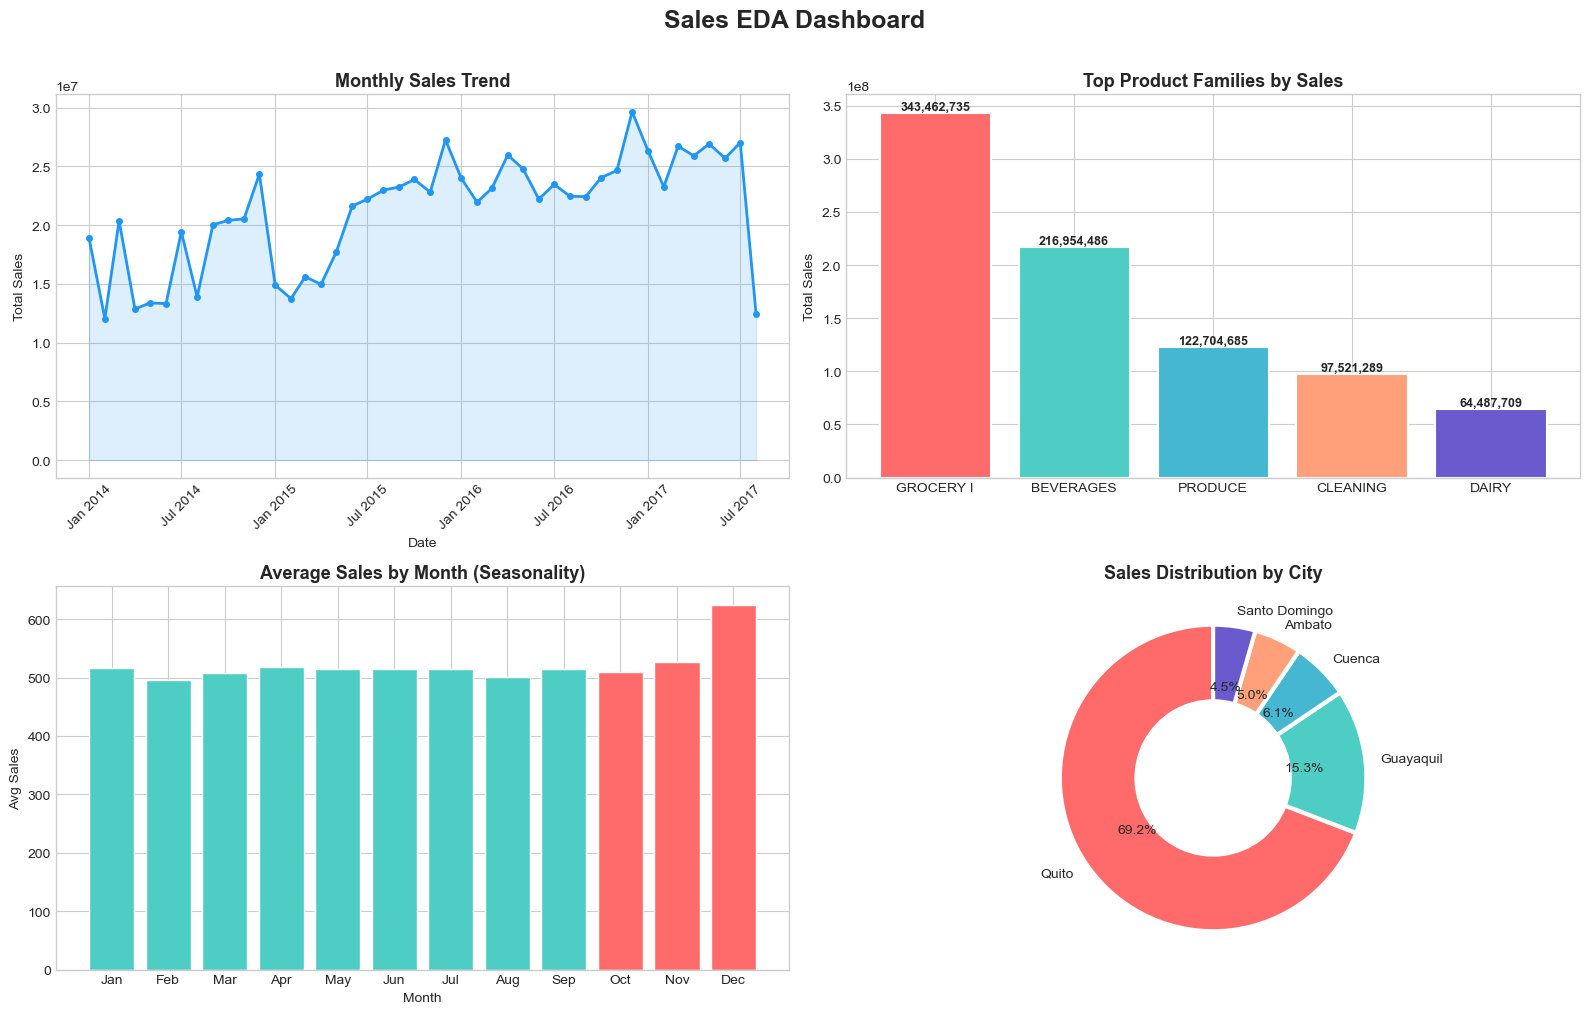

 EDA Dashboard saved as eda_dashboard.png


In [201]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Sales EDA Dashboard', fontsize=18, fontweight='bold', y=1.01)


# 1. Monthly Sales Trend

axes[0, 0].plot(monthly_sales['Date'], monthly_sales['Sales'],
                color='#2196F3', linewidth=2, marker='o', markersize=4)

axes[0, 0].fill_between(monthly_sales['Date'], monthly_sales['Sales'],
                        alpha=0.15, color='#2196F3')

axes[0, 0].set_title('Monthly Sales Trend', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Total Sales')

axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[0, 0].xaxis.get_majorticklabels(), rotation=45)


# 2. Sales by Product Family 

family_sales = df.groupby('Product')['Sales'].sum().sort_values(ascending=False).head(5)

bars = axes[0, 1].bar(family_sales.index, family_sales.values,
                     color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#6A5ACD'],
                     edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, family_sales.values):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 5000,
                    f'{val:,.0f}',
                    ha='center', va='bottom',
                    fontweight='bold', fontsize=9)

axes[0, 1].set_title('Top Product Families by Sales', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('Total Sales')


# 3. Monthly Seasonality

avg_by_month = df.groupby('Month')['Sales'].mean()

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
colors_month = ['#FF6B6B' if m in [10,11,12] else '#4ECDC4' for m in range(1,13)]

axes[1, 0].bar(month_names, avg_by_month.values,
               color=colors_month, edgecolor='white')

axes[1, 0].set_title('Average Sales by Month (Seasonality)', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('Avg Sales')
axes[1, 0].set_xlabel('Month')


# 4. Sales by City (instead of Region)

city_sales = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(5)

wedge_props = dict(width=0.5, edgecolor='white', linewidth=3)

axes[1, 1].pie(city_sales.values,
               labels=city_sales.index,
               autopct='%1.1f%%',
               startangle=90,
               wedgeprops=wedge_props,
               colors=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#6A5ACD'])

axes[1, 1].set_title('Sales Distribution by City', fontsize=13, fontweight='bold')


# Final Layout

plt.tight_layout()
plt.savefig('eda_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print(' EDA Dashboard saved as eda_dashboard.png')

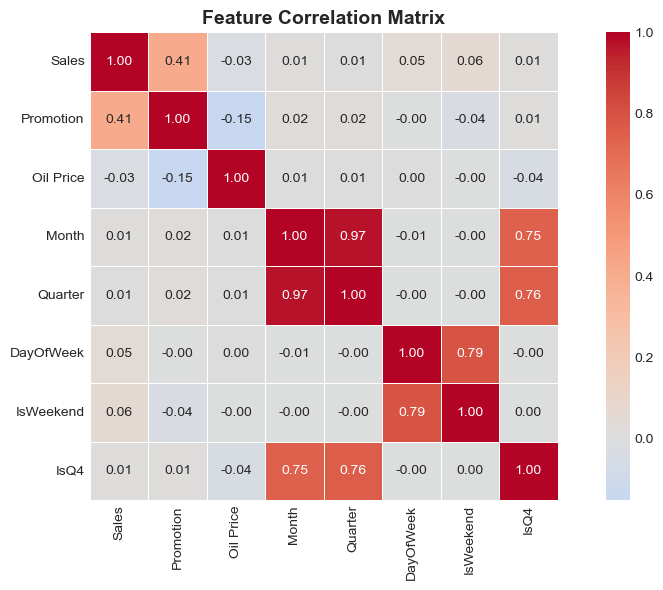

In [202]:
# Correlation Heatmap

fig, ax = plt.subplots(figsize=(10, 6))

# Use only available numeric features
numeric_cols = [
    'Sales', 
    'Promotion', 
    'Oil Price', 
    'Month', 
    'Quarter', 
    'DayOfWeek', 
    'IsWeekend', 
    'IsQ4'
]

corr = df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [203]:
# Prepare Features & Target

# Define feature columns
features = [
    'Month_Num', 
    'Quarter', 
    'IsQ4', 
    'Year',
    'Sales_Lag1', 
    'Sales_Lag3', 
    'Sales_Lag12',
    'Rolling_Mean_3', 
    'Rolling_Mean_6', 
    'Rolling_Std_3'
]

# Input (X) and Target (y)
X = monthly_sales[features]
y = monthly_sales['Sales']

# -------------------------------
# Time-based Train-Test Split
# (Last 6 months = Test set)
# -------------------------------
split_idx = len(X) - 6

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

# -------------------------------
# Output Info
# -------------------------------
print(f'Training samples : {len(X_train)}')
print(f'Testing samples  : {len(X_test)}')
print(f'Features used    : {features}')

Training samples : 38
Testing samples  : 6
Features used    : ['Month_Num', 'Quarter', 'IsQ4', 'Year', 'Sales_Lag1', 'Sales_Lag3', 'Sales_Lag12', 'Rolling_Mean_3', 'Rolling_Mean_6', 'Rolling_Std_3']


In [204]:
# Model Training

# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(
        n_estimators=100, random_state=42, max_depth=6
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=100, random_state=42, learning_rate=0.1
    )
}

results = {}
predictions = {}

# Train & evaluate models
for name, model in models.items():
    
    # Train model
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    
    # Evaluation Metrics
   
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    
    # Safe MAPE (avoid divide by zero)
    mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-8))) * 100
    
    # Store results
    results[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'MAPE (%)': mape
    }
    
    # Print results
    print(f'\n {name}')
    print(f'   MAE   : {mae:,.2f}')
    print(f'   RMSE  : {rmse:,.2f}')
    print(f'   R²    : {r2:.4f}')
    print(f'   MAPE  : {mape:.2f}%')


 Linear Regression
   MAE   : 1,705,573.96
   RMSE  : 2,398,864.19
   R²    : 0.7907
   MAPE  : 10.21%

 Random Forest
   MAE   : 3,246,823.14
   RMSE  : 4,868,639.00
   R²    : 0.1381
   MAPE  : 20.20%

 Gradient Boosting
   MAE   : 3,122,761.87
   RMSE  : 4,681,379.75
   R²    : 0.2031
   MAPE  : 19.44%


In [205]:
# Model Comparison

# Convert results to DataFrame
results_df = pd.DataFrame(results).T.round(2)

# Sort by best R² score
results_df = results_df.sort_values('R²', ascending=False)

print('\n=== Model Performance Comparison ===')
print(results_df.to_string())

# Select Best Model

best_model_name = results_df['R²'].idxmax()
best_model = models[best_model_name]

print(f'\n Best Model: {best_model_name} (R² = {results_df.loc[best_model_name, "R²"]})')


=== Model Performance Comparison ===
                          MAE        RMSE    R²  MAPE (%)
Linear Regression  1705573.96  2398864.19  0.79     10.21
Gradient Boosting  3122761.87  4681379.75  0.20     19.44
Random Forest      3246823.14  4868639.00  0.14     20.20

 Best Model: Linear Regression (R² = 0.79)


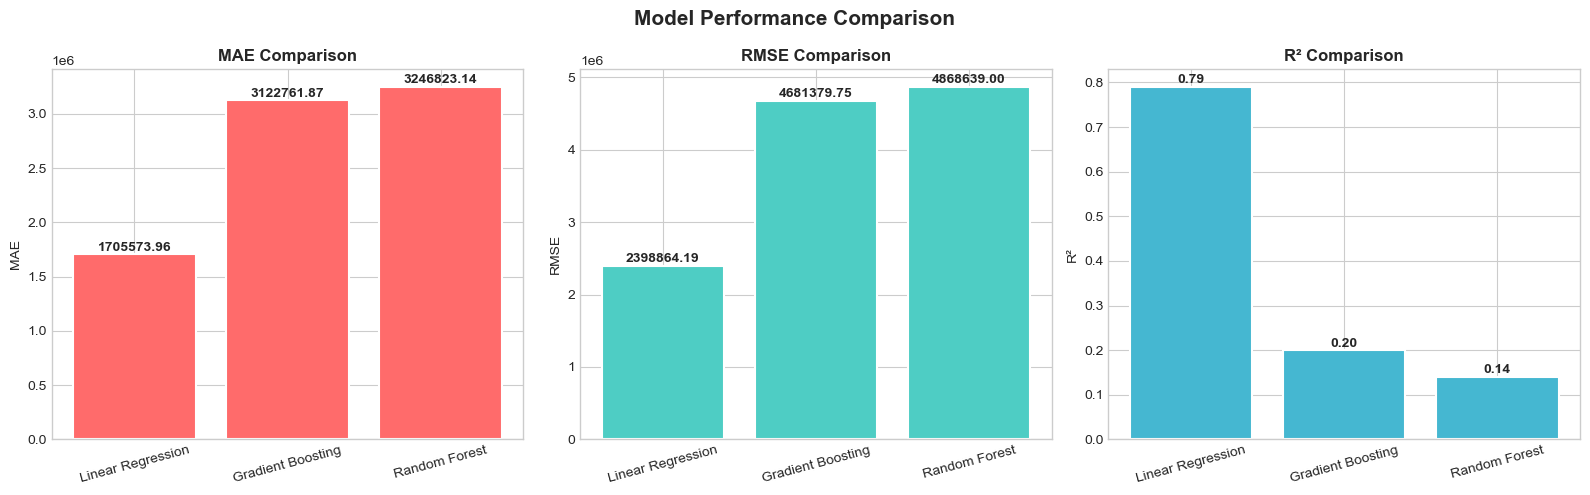

In [206]:
# ================================
# Model Comparison Bar Charts
# ================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['MAE', 'RMSE', 'R²']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for ax, metric, color in zip(axes, metrics, colors):
    vals = results_df[metric]
    
    bars = ax.bar(vals.index, vals.values,
                  color=color, edgecolor='white', linewidth=1.5)
    
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.01,
                f'{val:.2f}',
                ha='center', fontsize=10, fontweight='bold')
    
    ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=15)

plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [207]:
# Feature Importance

if hasattr(best_model, 'feature_importances_'):
    
    importances = pd.Series(best_model.feature_importances_, index=features)
    importances = importances.sort_values(ascending=True)
    
    fig, ax = plt.subplots(figsize=(9, 5))
    
    ax.barh(importances.index, importances.values,
            color='#4ECDC4', edgecolor='white')
    
    ax.set_title(f'Feature Importance — {best_model_name}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance Score')
    
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

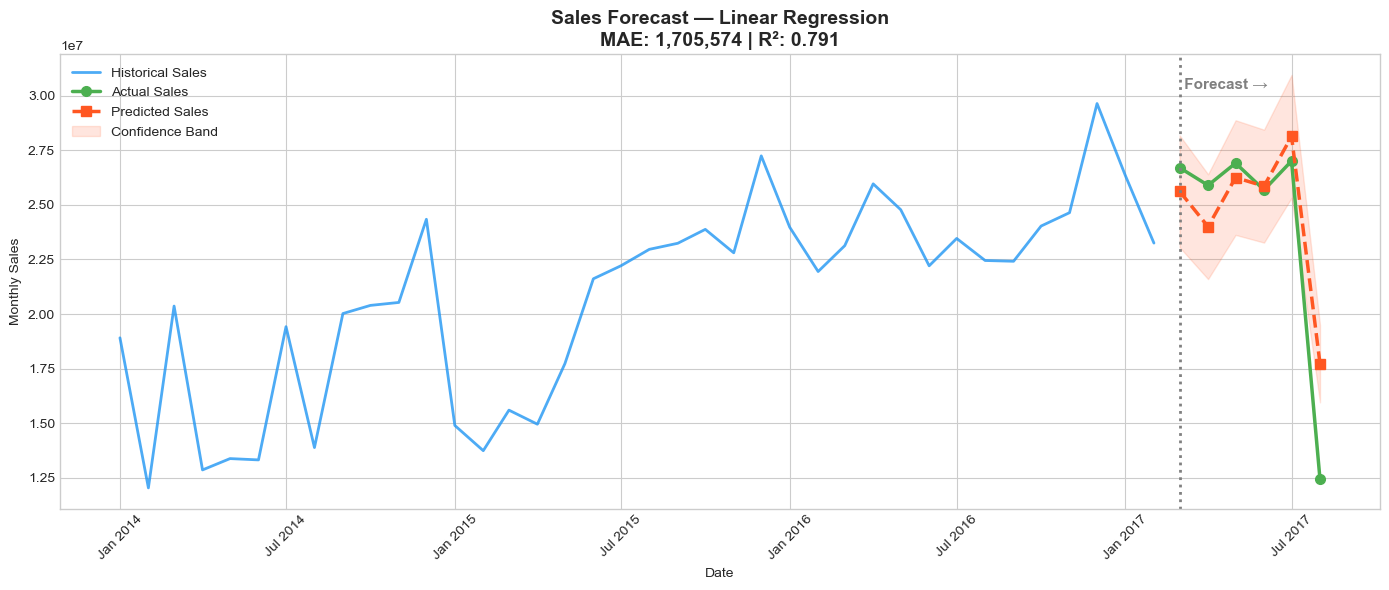

 Forecast chart saved as sales_forecast.png


In [208]:
# Actual vs Predicted

best_pred = predictions[best_model_name]

test_dates  = monthly_sales['Date'].iloc[split_idx:]
train_dates = monthly_sales['Date'].iloc[:split_idx]
train_sales = monthly_sales['Sales'].iloc[:split_idx]

fig, ax = plt.subplots(figsize=(14, 6))

# Historical data
ax.plot(train_dates, train_sales,
        color='#2196F3', linewidth=2,
        label='Historical Sales', alpha=0.8)

# Actual values
ax.plot(test_dates, y_test.values,
        color='#4CAF50', linewidth=2.5,
        marker='o', markersize=7,
        label='Actual Sales')

# Predicted values
ax.plot(test_dates, best_pred,
        color='#FF5722', linewidth=2.5,
        linestyle='--', marker='s', markersize=7,
        label='Predicted Sales')

# Confidence band
ax.fill_between(test_dates,
                best_pred * 0.9,
                best_pred * 1.1,
                alpha=0.15, color='#FF5722',
                label='Confidence Band')

# Forecast divider
ax.axvline(x=test_dates.iloc[0],
           color='gray', linestyle=':', linewidth=2)

ax.text(test_dates.iloc[0],
        ax.get_ylim()[1] * 0.95,
        ' Forecast →',
        fontsize=11, color='gray', fontweight='bold')

# Title
ax.set_title(
    f'Sales Forecast — {best_model_name}\n'
    f'MAE: {mean_absolute_error(y_test, best_pred):,.0f} | '
    f'R²: {r2_score(y_test, best_pred):.3f}',
    fontsize=14, fontweight='bold'
)

ax.set_xlabel('Date')
ax.set_ylabel('Monthly Sales')

ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('sales_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print(' Forecast chart saved as sales_forecast.png')

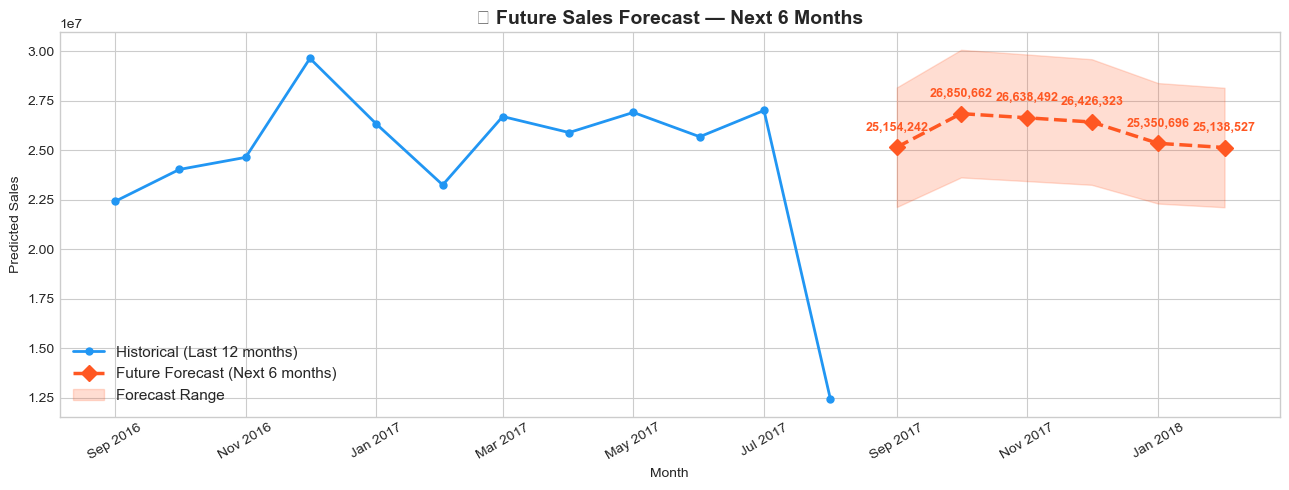

 Future forecast saved!


In [209]:
# Future Forecast: Next 6 Months

future_months = []
last_date = monthly_sales['Date'].max()

for i in range(1, 7):
    
    future_date = last_date + pd.DateOffset(months=i)
    
    row = {
        'Month_Num'   : future_date.month,
        'Quarter'     : (future_date.month - 1) // 3 + 1,
        'IsQ4'        : int(future_date.month in [10, 11, 12]),
        'Year'        : future_date.year,
        
        # Lag Features (safe indexing)
        'Sales_Lag1'  : monthly_sales['Sales'].iloc[-1],
        'Sales_Lag3'  : monthly_sales['Sales'].iloc[-3],
        'Sales_Lag12' : monthly_sales['Sales'].iloc[-12] if len(monthly_sales) >= 12 else monthly_sales['Sales'].mean(),
        
        # Rolling stats
        'Rolling_Mean_3' : monthly_sales['Sales'].iloc[-3:].mean(),
        'Rolling_Mean_6' : monthly_sales['Sales'].iloc[-6:].mean(),
        'Rolling_Std_3'  : monthly_sales['Sales'].iloc[-3:].std(),
        
        'Date' : future_date
    }
    
    future_months.append(row)

# Create DataFrame
future_df = pd.DataFrame(future_months)

# Predict future sales
future_pred = best_model.predict(future_df[features])

# Plot Future Forecast

fig, ax = plt.subplots(figsize=(13, 5))

# Last 12 months (historical)
ax.plot(monthly_sales['Date'].iloc[-12:],
        monthly_sales['Sales'].iloc[-12:],
        color='#2196F3', linewidth=2,
        marker='o', markersize=5,
        label='Historical (Last 12 months)')

# Future predictions
ax.plot(future_df['Date'], future_pred,
        color='#FF5722', linewidth=2.5,
        linestyle='--', marker='D', markersize=8,
        label='Future Forecast (Next 6 months)')

# Confidence band
ax.fill_between(future_df['Date'],
                future_pred * 0.88,
                future_pred * 1.12,
                alpha=0.2, color='#FF5722',
                label='Forecast Range')

# Value labels
for date, pred in zip(future_df['Date'], future_pred):
    ax.annotate(f'{pred:,.0f}', (date, pred),
                textcoords='offset points',
                xytext=(0, 12),
                ha='center', fontsize=9,
                color='#FF5722', fontweight='bold')

# Title & labels
ax.set_title('🔮 Future Sales Forecast — Next 6 Months',
             fontsize=14, fontweight='bold')

ax.set_xlabel('Month')
ax.set_ylabel('Predicted Sales')

ax.legend(fontsize=11)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.savefig('future_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print(' Future forecast saved!')

In [210]:
# STORE SALES BUSINESS REPORT

print('=' * 60)
print('        🏬 STORE SALES INSIGHTS REPORT')
print('=' * 60)

# ---- Fix column names ----
df.columns = df.columns.str.lower().str.strip()

# Convert correct date column
df['date'] = pd.to_datetime(df['order date'])

# ---- Key Metrics ----
total_sales = df['sales'].sum()

daily_sales = df.groupby('date')['sales'].sum()
avg_daily_sales = daily_sales.mean()

best_day = daily_sales.idxmax().strftime('%d %B %Y')

best_store = df.groupby('store')['sales'].sum().idxmax()
top_store_sales = df.groupby('store')['sales'].sum().max()

best_product = df.groupby('product')['sales'].sum().idxmax()

promo_impact = df.groupby('promotion')['sales'].mean()

# (Assume profit = 10% of sales if not given)
total_profit = total_sales * 0.1
profit_margin = (total_profit / total_sales) * 100

# ---- Revenue Overview ----
print(f'\n📌 Revenue Overview')
print(f'   Total Sales          : ${total_sales:>12,.2f}')
print(f'   Estimated Profit     : ${total_profit:>12,.2f}')
print(f'   Profit Margin        : {profit_margin:>11.1f}%')
print(f'   Avg Daily Sales      : ${avg_daily_sales:>12,.2f}')

# ---- Performance Highlights ----
print(f'\n📌 Performance Highlights')
print(f'   Best Sales Day       : {best_day}')
print(f'   Top Store            : Store {best_store}')
print(f'   Top Product Category : {best_product}')

# ---- Promotion Impact ----
print(f'\n📌 Promotion Impact')
print(f'   Avg Sales (No Promo) : ${promo_impact.get(0,0):,.2f}')
print(f'   Avg Sales (Promo)    : ${promo_impact.get(1,0):,.2f}')

# ---- Model Performance ----
print(f'\n📌 Model Performance ({best_model_name})')
print(f'   R² Score             : {results_df.loc[best_model_name, "R²"]:.4f}')
print(f'   MAE                  : ${results_df.loc[best_model_name, "MAE"]:,.2f}')
print(f'   MAPE                 : {results_df.loc[best_model_name, "MAPE (%)"]:.2f}%')

# ---- Forecast ----
print(f'\n📌 Next 6 Month Forecast (Projected)')
for date, pred in zip(future_df['Date'], future_pred):
    print(f'   {date.strftime("%B %Y"):15s}: ${pred:>10,.2f}')

# ---- Recommendations ----
print('\n📌 Recommendations')
print('   → Increase stock during high-demand periods')
print('   → Focus on top-selling product categories')
print('   → Use promotions strategically to boost sales')
print('   → Improve performance of low-performing stores')
print('   → Plan inventory using forecasting insights')

print('=' * 60)

        🏬 STORE SALES INSIGHTS REPORT

📌 Revenue Overview
   Total Sales          : $1,073,644,951.42
   Estimated Profit     : $107,364,495.14
   Profit Margin        :        10.0%
   Avg Daily Sales      : $  637,556.38

📌 Performance Highlights
   Best Sales Day       : 01 April 2017
   Top Store            : Store 44
   Top Product Category : GROCERY I

📌 Promotion Impact
   Avg Sales (No Promo) : $260.71
   Avg Sales (Promo)    : $467.57

📌 Model Performance (Linear Regression)
   R² Score             : 0.7900
   MAE                  : $1,705,573.96
   MAPE                 : 10.21%

📌 Next 6 Month Forecast (Projected)
   September 2017 : $25,154,241.64
   October 2017   : $26,850,661.82
   November 2017  : $26,638,492.36
   December 2017  : $26,426,322.89
   January 2018   : $25,350,696.37
   February 2018  : $25,138,526.90

📌 Recommendations
   → Increase stock during high-demand periods
   → Focus on top-selling product categories
   → Use promotions strategically to boost sale